# Plot model domains
- This script is used to visualize nested domains.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import string
from matplotlib.ticker import ScalarFormatter
home_path = '/gws/ssde/j25a/duicv/yuansun/'

In [2]:
domain_path = f'{home_path}0_wrf-cstm_GM-HK/runs/TranUrbAlb_HK/configuration/WPS/geogrid/'
extent_list = []
for d in range(1, 5):
    domain = xr.open_dataset(f'{domain_path}geo_em.d0{d}.nc')
    domain_lat = domain['XLAT_M'].squeeze()
    domain_lon = domain['XLONG_M'].squeeze()
    domain_lat_min, domain_lat_max = domain_lat.min().item(), domain_lat.max().item()
    domain_lon_min, domain_lon_max = domain_lon.min().item(), domain_lon.max().item()
    extent_list.append([domain_lon_min, domain_lon_max, domain_lat_min, domain_lat_max])

In [3]:
labelcolor = '#6b6b6b'
linewidth = 0.5
proj = ccrs.PlateCarree()
labelsize = 6
ax1_extent = [50, 180, -30, 60]
alpha=0.5
tick_length = 2
boundarywidth = 0.5
ticklabel_pad = 0.1

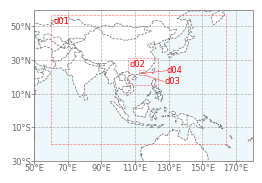

In [4]:
fig, ax = plt.subplots(figsize=(2.5, 1.75), subplot_kw={'projection': proj})
ax.add_feature(cfeature.BORDERS, edgecolor=labelcolor, linewidth=linewidth, linestyle='--')
ax.add_feature(cfeature.COASTLINE, edgecolor=labelcolor, linewidth=linewidth, linestyle='--')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
for i in range(4):
    domain_extent = extent_list[i]
    if i ==3:
        linestyle = '-'
        facecolor = 'red'
    else:
        linestyle = '--'   
        facecolor = 'none' 
    rect = Rectangle((domain_extent[0], domain_extent[2]),
                     domain_extent[1] - domain_extent[0],
                     domain_extent[3] - domain_extent[2],
                     edgecolor='red', facecolor=facecolor, linewidth=linewidth,
                     linestyle=linestyle, alpha = 0.5,
                     transform=ccrs.PlateCarree())
    ax.add_patch(rect)
    if i<2:
        ax.text(domain_extent[0]+1, domain_extent[3]-1, f'd0{i+1}', color = 'red', fontsize= labelsize, ha='left', va='top')
    else:
        ax.text(domain_extent[0]+15, domain_extent[3]+8*i-20, f'd0{i+1}', color = 'red', fontsize= labelsize, ha='left', va='top') 
        ax.plot([domain_extent[1], domain_extent[0] + 15], [domain_extent[2], domain_extent[3]+8*i-23], color='red', 
                linewidth=0.3) 
ax.set_extent(ax1_extent, crs=proj)
ax.set_xticks(range(int(ax1_extent[0]), int(ax1_extent[1])+2, 20), crs = proj)  # Adjust step size as needed
ax.set_yticks(range(int(ax1_extent[2]), int(ax1_extent[3]), 20), crs = proj)  # Adjust step size as needed 
ax.grid('both', linewidth=linewidth, color=labelcolor, alpha=alpha, linestyle='--') 
ax.tick_params(axis='both', labelsize=labelsize, length=tick_length, pad=ticklabel_pad,
                width=boundarywidth,colors=labelcolor)   
ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
ax.yaxis.set_major_formatter(LatitudeFormatter())
for spine in ax.spines.values():
    spine.set_linewidth(boundarywidth)
    spine.set_edgecolor(labelcolor)
plt.subplots_adjust(left=0.1, right=0.975, bottom=0.045, top=0.97)  
plt.savefig('domain.png', dpi=600) 
plt.savefig('domain.pdf', dpi=600) 